# Comparing the five SR methods

The package bundles five flux estimators behind one pipeline; this tutorial
runs all of them on **identical preprocessed data** with
`compare_methods`, quantifies their pairwise agreement with
`method_agreement`, and demonstrates the free-convection fallback for
near-calm conditions.

| Method | Needs $u_*$? | Needs $z_m$? | Needs EC calibration? |
|--------|:---:|:---:|:---:|
| `snyder` | no | no | **yes** |
| `chen97` | yes | no | **yes** |
| `fvs` | yes | yes | no |
| `castellvi` | yes | yes | no |
| `wavelet` | no | no | **yes** |

`fvs` and `castellvi` are height-dependent: they close the flux through
Monin–Obukhov similarity theory and therefore need the measurement height
`z_m` (sensor height above the zero-plane displacement, in metres). The
[method-selection guide](../methods.md) discusses the trade-offs in detail.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from surface_renewal import run_surface_renewal, PipelineConfig

# A light, recessive plot style: hairline grid behind the data, no chart junk.
plt.rcParams.update({
    "figure.figsize": (9.0, 3.6),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelcolor": "#52514e",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "lines.linewidth": 1.8,
    "legend.frameon": False,
})

# Fixed series colors; each quantity keeps its color across all figures.
C_BLUE, C_AQUA, C_YELLOW, C_GREEN, C_VIOLET, C_INK = (
    "#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#52514e",
)

## Synthetic input data

The tutorials are self-contained: instead of shipping a large raw data file,
each one generates a 4-hour, 10 Hz record with the structure the SR methods
look for — gradual warming **ramps** that end in a sharp temperature drop as
the heated air parcel is swept away and renewed. With your own data you would
skip this cell and pass a `DataFrame` (or a CSV/Parquet path) with columns
`T`, `u`, `v`, `w` and, optionally, `Rn` and `G` — see the
[quick start](../quickstart.md) for the input conventions. A stand-alone copy
of a similar generator ships with the repository as `scripts/make_synthetic.py`.

In [2]:
def make_synthetic(fs=10.0, hours=4.0, seed=42, wind=1.0):
    """Synthetic high-frequency record with surface-renewal ramp structure.

    Temperature follows the classic SR ramp — a slow rise ended by a sharp
    drop (60 s period) — whose amplitude grows toward "midday" and fades
    again (the ``env`` envelope). The wind components share part of the ramp
    signal so the record carries a realistic w'T' covariance and a well-posed
    friction velocity. ``wind`` scales all wind components (1.0 = breezy,
    small values = near-calm convective conditions).
    """
    rng = np.random.default_rng(seed)
    n = int(fs * 3600 * hours)
    t = np.arange(n) / fs

    # Convective "activity" envelope: ramps grow toward midday, then fade.
    env = 0.3 + 0.7 * np.sin(np.pi * t / t[-1])
    # Classic SR ramp: slow rise, sharp drop, 60 s period.
    ramp = 2.0 * ((t % 60.0) / 60.0) - 1.0

    T = 298.15 + 0.4 * env * ramp + 0.05 * rng.standard_normal(n)
    du = 0.5 * env * ramp + 0.5 * rng.standard_normal(n)  # streamwise gusts
    u = wind * (2.5 + du)
    v = wind * (0.1 + 0.5 * du + 0.3 * rng.standard_normal(n))
    w = wind * (0.2 * du + 0.15 * rng.standard_normal(n))

    idx = pd.Timestamp("2023-06-01 08:00") + pd.to_timedelta(t, unit="s")
    df = pd.DataFrame({"T": T, "u": u, "v": v, "w": w}, index=idx)

    # Radiation terms (W m^-2) so the latent-heat residual is exercised.
    solar = 400.0 + 200.0 * np.sin(np.pi * t / t[-1])
    df["Rn"] = solar + 20.0 * rng.standard_normal(n)
    df["G"] = 0.1 * solar + 5.0 * rng.standard_normal(n)
    return df

## Run every method on the same preprocessed record

`compare_methods` reads, despikes and rotates the data **once**, then
evaluates each method on that identical cleaned series — so the only thing
that varies between the `H_*` columns is the flux estimator itself. Methods
that need `z_m` are silently skipped (with a logged warning) when it is not
configured, so we set it here.

In [3]:
from surface_renewal import compare_methods, method_agreement

df = make_synthetic()

cfg = PipelineConfig(
    fs=10.0,
    block="30min",
    rotation="double",
    z_m=2.0,           # required by fvs / castellvi
)

wide = compare_methods(df, cfg=cfg)
wide.round(2)

,H_snyder,H_chen97,H_fvs,H_castellvi,H_wavelet,ustar,stdT,CT2,passed,zeta
2023-06-01 08:29:59.900,5.70,-18.19,-11.45,1.13,6.40,0.22,0.11,0.01,True,0.02
2023-06-01 08:59:59.900,9.70,-44.63,-17.77,1.98,10.09,0.23,0.17,0.01,True,0.03
2023-06-01 09:29:59.900,13.29,-60.70,-23.54,2.77,12.84,0.24,0.21,0.01,True,0.04
2023-06-01 09:59:59.900,15.35,-102.98,-27.01,3.19,14.31,0.25,0.23,0.01,True,0.04
2023-06-01 10:29:59.900,14.89,-68.79,-26.65,3.10,14.31,0.25,0.23,0.01,True,0.04
2023-06-01 10:59:59.900,13.32,-65.29,-23.50,2.76,12.87,0.24,0.21,0.01,True,0.04
2023-06-01 11:29:59.900,9.85,-32.96,-17.57,2.06,10.00,0.23,0.17,0.01,True,0.03
2023-06-01 11:59:59.900,5.86,-31.39,-11.49,1.16,6.47,0.22,0.11,0.01,True,0.02


Two things stand out immediately, and both are expected:

- **Scale differences.** `snyder`, `chen97` and `wavelet` are *uncalibrated*
  magnitudes — each is defined only up to the block-scale factor $\alpha$
  fitted in [tutorial 3](03_calibration.ipynb) — while `fvs` and `castellvi`
  are calibration-free. Comparing raw uncalibrated numbers across methods
  therefore mixes different scales.
- **Sign conventions differ.** `chen97` and `fvs` carry the sign of
  $S_3(\tau^*)$, which is *negative* over daytime warming ramps, so their
  fluxes come out negative on this record while `snyder`, `castellvi` and
  `wavelet` report the (positive) ramp magnitude. A fitted $\alpha$ absorbs
  the sign along with the scale.

For a like-for-like view of the temporal behaviour, plot the flux
**magnitudes**:

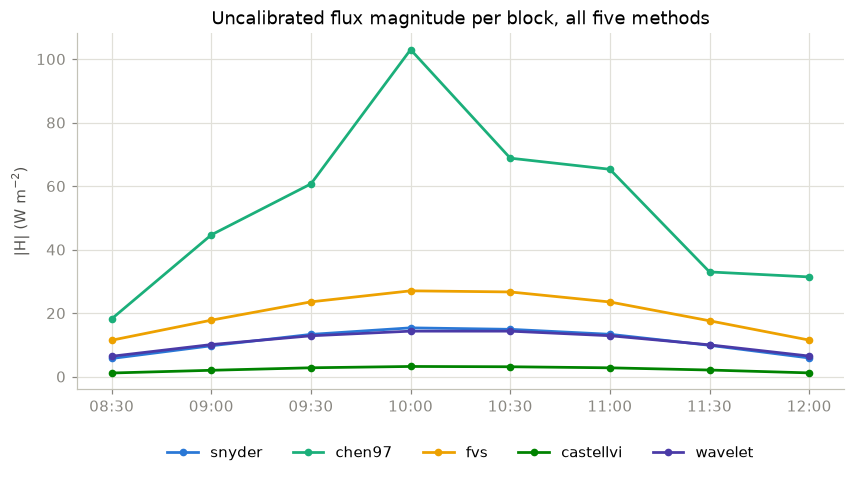

In [4]:
methods = ["snyder", "chen97", "fvs", "castellvi", "wavelet"]
colors = [C_BLUE, C_AQUA, C_YELLOW, C_GREEN, C_VIOLET]

fig, ax = plt.subplots(figsize=(9.0, 4.2))
for m, c in zip(methods, colors):
    ax.plot(wide.index, wide[f"H_{m}"].abs(), color=c, marker="o", ms=4, label=m)
ax.set_ylabel("|H| (W m$^{-2}$)")
ax.set_title("Uncalibrated flux magnitude per block, all five methods")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(ncols=5, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.show()

All five track the convective envelope (low → high → low), which is the
behaviour that survives calibration; the vertical offsets are the
method-specific scales that $\alpha$ removes.

## Quantifying agreement

`method_agreement` computes, for every method pair over blocks that passed
the stability screen: the least-squares **slope** through the origin, the
**rmse** and mean **bias** of the differences, and the number of contributing
blocks **N**. Note the statistics operate on the *signed* fluxes, so pairs
with opposite sign conventions show negative slopes.

In [5]:
method_agreement(wide).round(3)

slope    rmse    bias  N
method_a  method_b                           
snyder    chen97    -4.981  70.178 -64.110  8
          fvs       -1.791  32.276 -30.869  8
          castellvi  0.207   9.167  -8.725  8
          wavelet    0.978   0.598  -0.085  8
chen97    fvs        0.344  38.848  33.241  8
          castellvi -0.040  61.166  55.384  8
          wavelet   -0.187  69.871  64.025  8
fvs       castellvi -0.115  23.111  22.143  8
          wavelet   -0.546  32.033  30.784  8
castellvi wavelet    4.718   8.927   8.641  8

On real data this table is the quickest way to see which formulations behave
interchangeably at your site (slope near ±1, small rmse) and which disagree
systematically. Here, for example, `snyder` and `wavelet` land within a few
percent of each other — they measure the same ramps two different ways.

## The free-convection fallback

The $u_*$-based methods (`chen97`, `fvs`, `castellvi`) degrade as
$u_* \to 0$: exactly the near-calm, strongly convective conditions common on
summer afternoons. Setting `free_convection_fallback=True` substitutes a
$\sigma_T$-only free-convection estimate on blocks that are simultaneously
low-wind (`ustar < fc_ustar_max`), strongly unstable
(`zeta < fc_zeta_max`) and carrying an upward primary flux. The per-block
choice is recorded in `flux_method_used`.

Scaling the synthetic wind down to near-calm conditions makes the fallback
engage on the most unstable midday blocks:

In [6]:
import dataclasses

df_calm = make_synthetic(wind=0.3)  # near-calm: u* ~ 0.07 m/s

cfg_fc = dataclasses.replace(cfg, method="castellvi", free_convection_fallback=True)
out_fc = run_surface_renewal(df_calm, cfg=cfg_fc)
out_fc[["H_uncal", "ustar", "zeta", "flux_method_used", "passed"]].round(3)

,H_uncal,ustar,zeta,flux_method_used,passed
2023-06-01 08:29:59.900,3.012,0.066,-0.234,primary,True
2023-06-01 08:59:59.900,5.864,0.069,-0.391,primary,True
2023-06-01 09:29:59.900,8.610,0.073,-0.497,primary,True
2023-06-01 09:59:59.900,30.708,0.076,-0.523,free_convection,True
2023-06-01 10:29:59.900,30.677,0.075,-0.529,free_convection,True
2023-06-01 10:59:59.900,8.547,0.073,-0.490,primary,True
2023-06-01 11:29:59.900,6.223,0.069,-0.431,primary,True
2023-06-01 11:59:59.900,3.135,0.066,-0.246,primary,True


Blocks with `zeta` below the default `fc_zeta_max = -0.5` switched to
`"free_convection"`; the calmer and more unstable the block, the more the
$u_*$-based estimate would have been degraded. On a windy record
(`wind=1.0`) the same configuration never triggers — the fallback is a
safety net, not a competing method.

## Where to go next

- **[Calibration tutorial](03_calibration.ipynb)** — fit $\alpha$ for the
  uncalibrated methods against an eddy-covariance reference.
- The CLI mirrors this workflow:
  `python -m surface_renewal.compute data.csv --fs 10 --compare --z-m 2.0`
  (see the [CLI reference](../cli.md)).